In [ ]:
from google.colab import drive

In [ ]:
drive.mount('\content\drive')

In [1]:
! pip install kaggle

In [2]:
! mkdir ~/.kaggle

In [3]:
cp kaggle.json ~/.kaggle/

In [4]:
! chmod 600 ~/.kaggle/kaggle.json

In [5]:
! kaggle datasets download -d itamargr/dfdc-faces-of-the-train-sample

100% 3.64G/3.64G [03:34<00:00, 22.2MB/s]
100% 3.64G/3.64G [03:34<00:00, 18.2MB/s]


In [ ]:
! unzip "/content/dfdc-faces-of-the-train-sample.zip"

Below we First load the weights into the model. Then we freeze the layers of the model.

In [7]:
import torch
from Deepphys import DeepPhys
import torch.nn as nn
from Deepphys import Attention_mask

import os
import cv2
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image


import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
loaded_state_dict = torch.load('/content/UBFC-rPPG_DeepPhys.pth',map_location=torch.device('cpu'))


In [9]:
# In case the keys have the 'module.' prefix, remove it to match the keys in the current model
if list(loaded_state_dict.keys())[0].startswith('module.'):
    loaded_state_dict = {k[7:]: v for k, v in loaded_state_dict.items()}


In [10]:
# Initialize the model with the same parameters as the original model
current_model3 = DeepPhys(in_channels=3, nb_filters1=32, nb_filters2=64, kernel_size=3,
                         dropout_rate1=0.8, dropout_rate2=0.8, pool_size=(2, 2), nb_dense=128, img_size=72)


In [ ]:
list(current_model.parameters())

In [11]:
# Load the matched state_dict into the model
current_model3.load_state_dict(loaded_state_dict)


<All keys matched successfully>

In [13]:
num_params=0
for p in current_model.parameters():
    if p.requires_grad:
        num_params += p.numel()

print(f"Number of trainable parameters in the model: {num_params}")

Number of trainable parameters in the model: 2228643


In [12]:
def freeze_final_dense2_layer(model):
    for name, param in model.named_parameters():
        if not (name == 'final_dense_2.weight' or name == 'final_dense_2.bias'):
            param.requires_grad = False

In [13]:
def check_layers_frozen(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Requires Grad: {param.requires_grad}, Grad_fn:{param.grad_fn}")

In [ ]:
# Freeze only the final_dense_2 layer
freeze_final_dense2_layer(current_model3)
check_layers_frozen(current_model3)

end of defining the model. Next thing is to Manage the data


In [15]:
transform = transforms.Compose([
    transforms.Resize((72, 72)),
    transforms.RandomHorizontalFlip(),  # Add horizontal flipping
    transforms.RandomVerticalFlip(),    # Add vertical flipping
    transforms.ToTensor(),
])


In [16]:
# Define your data directories
train_data_dir = "/content/train"
val_data_dir = "/content/validation"


In [17]:
# Define a save path prefix
save_path_prefix = '/content/trained_model'

In [18]:
# Create data loaders
batch_size = 128
train_dataset = torchvision.datasets.ImageFolder(train_data_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=2)

val_dataset = torchvision.datasets.ImageFolder(val_data_dir, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [30]:
data_iter = iter(train_loader)  # Use train_loader or val_loader as needed

In [19]:
from torch.utils.tensorboard import SummaryWriter

In [20]:
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for binary classification
# optimizer = optim.Adam(current_model3.parameters(), lr=0.01)


In [21]:
from torch.optim import RMSprop
import torch.nn as nn

# Define your regularization strength (lambda)
lmbda = 0.03

# Create an optimizer with RMSprop and L2 regularization
optimizer = RMSprop(current_model3.parameters(), lr=0.0001, alpha=0.9, weight_decay=lmbda)


In [52]:
writer = SummaryWriter(log_dir='logs')  # Set the log directory as you prefer

In [22]:
num_epochs=10

In [23]:
from tqdm import tqdm

# Initialize variables to track the best validation accuracy and epoch number
best_acc = 0.0
best_epoch = -1
start_epoch = 0

# Load the saved checkpoint (if resuming training)
try:
    checkpoint = torch.load('model_checkpoint.pth')
    current_model3.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['accuracy']
    print(f'Resuming training from epoch {start_epoch}')
except FileNotFoundError:
    print('Starting training from scratch')

Starting training from scratch


In [24]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [25]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
current_model3.to(device)

In [27]:
# Initialize lists to store the accuracy, loss, AUC, and ROC values
train_acc_history = []
train_loss_history = []
train_auc_history = []
val_acc_history = []
val_loss_history = []
val_auc_history = []

for epoch in range(num_epochs):
    print(f'Epoch {epoch + 1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'validation']:
        if phase == 'train':
            current_model3.train()
            dataloader = train_loader
        else:
            current_model3.eval()
            dataloader = val_loader  # Use the validation dataloader for validation

        running_loss = 0.0
        running_corrects = 0
        total_samples = 0  # To keep track of the total number of samples
        all_labels = []
        all_outputs = []

        # Use tqdm to display a progress bar
        for inputs, labels in tqdm(dataloader, desc=f'Epoch {epoch + 1} - {phase}'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = current_model3(inputs)
                outputs2 = current_model3(inputs)
                labels = labels.unsqueeze(1).float()  # This is the additional line to ensure shape matches
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                l2_reg = 0.0
                for param in current_model3.parameters():
                  l2_reg += torch.norm(param)
                loss += lmbda * l2_reg

            running_loss += loss.item()
            if phase == 'train':
                    loss.backward()
                    optimizer.step()

            binary_output = (outputs2 >= 0.5).float()
            running_corrects += torch.sum(binary_output == labels)
            total_samples += inputs.size(0)

            # Append labels and outputs for AUC and ROC calculations
            all_labels.extend(labels.cpu().numpy())
            all_outputs.extend(outputs2.cpu().detach().numpy())

        # Calculate AUC and ROC
        fpr, tpr, _ = roc_curve(all_labels, all_outputs)
        roc_auc = auc(fpr, tpr)

        epoch_loss = running_loss / inputs.size(0)
        epoch_acc = (running_corrects.double() / total_samples) * 100

        # Store the accuracy, loss, AUC, and ROC values
        if phase == 'train':
            print(f'Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.4f}')
            print(f'Number of correct predicts : {running_corrects}/{total_samples}')  # Printing number of correct items predicted by the model

            train_acc_history.append(epoch_acc)
            train_loss_history.append(epoch_loss)
            train_auc_history.append(roc_auc)
        else:
            print(f'Loss: {loss.item():.4f} Accuracy: {epoch_acc:.4f}')
            print(f'AUC: {roc_auc:.4f}')
            print("\n")

            val_acc_history.append(epoch_acc)
            val_loss_history.append(epoch_loss)
            val_auc_history.append(roc_auc)

        # Check if the current model has better validation accuracy
        if phase == 'validation' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_epoch = epoch

            # Save the current model as a checkpoint
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': current_model3.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss,
                'accuracy': epoch_acc,
            }
            torch.save(checkpoint, '/content/model_checkpoint.pth')

    print()

print('Training complete')


Epoch 1/10
----------


Epoch 1 - train: 100%|██████████| 734/734 [02:58<00:00,  4.11it/s]


Loss: 405.9560 Accuracy: 77.7322
Number of correct predicts : 72954/93853


Epoch 1 - validation: 100%|██████████| 241/241 [00:48<00:00,  4.98it/s]


Loss: 16.4139 Accuracy: 80.4215
AUC: 0.5294



Epoch 2/10
----------


...

Loss: 405.4407 Accuracy: 77.9453
Number of correct predicts : 73154/93853


Epoch 3 - validation: 100%|██████████| 241/241 [00:43<00:00,  5.51it/s]


Loss: 16.3955 Accuracy: 80.4215
AUC: 0.5177



Epoch 4/10
----------


Epoch 4 - train:  12%|█▏        | 90/734 [00:17<02:03,  5.20it/s]


KeyboardInterrupt: ignored

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc

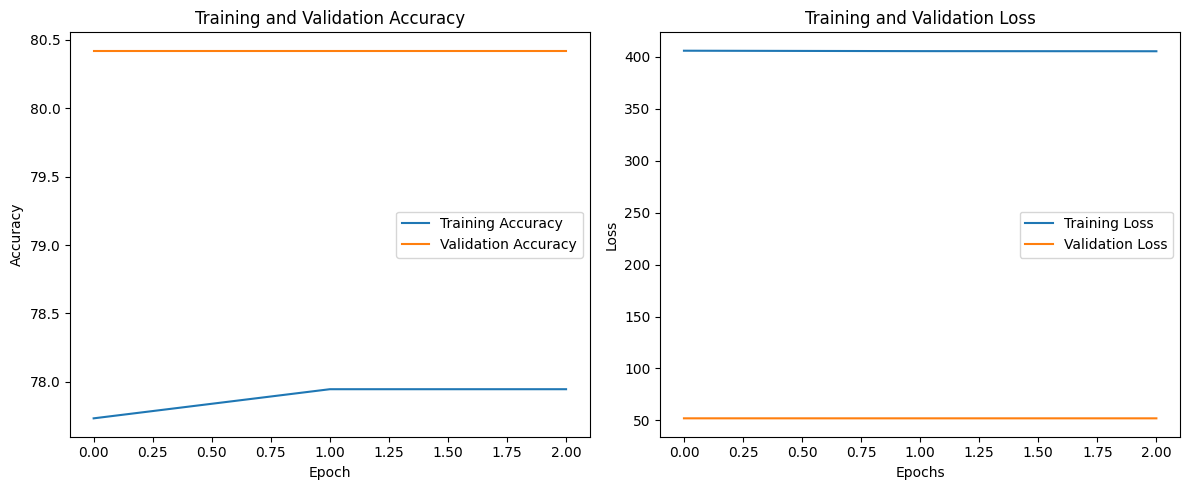

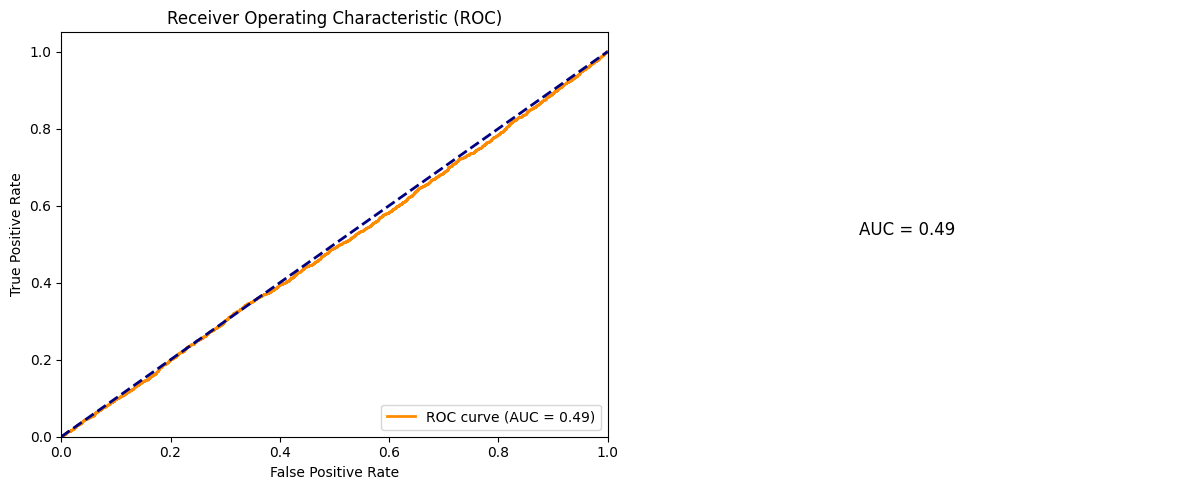

In [29]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([acc.cpu() for acc in train_acc_history], label='Training Accuracy')
plt.plot([acc.cpu() for acc in val_acc_history], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training and Validation Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

# Plot ROC Curve and Calculate AUC
fpr, tpr, _ = roc_curve(all_labels, all_outputs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')

# You can also show the AUC value
plt.subplot(1, 2, 2)
plt.text(0.5, 0.5, f'AUC = {roc_auc:.2f}', fontsize=12, ha='center')
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
torch.save(model_checkpoint, f'/content/model_checkpoint_PresetI.pth')